**Step 1 & 2** - **Project Setup and Data Loading**: This section initializes the project environment. We load the dataset into a Pandas DataFrame. The objective of this project is to predict "Profile Popularity." Instead of predicting the exact number of likes (regression), we will examine the distribution of likes_received to prepare for a classification approach.Description: This section initializes the project environment. We load the dataset into a Pandas DataFrame. The objective of this project is to predict "Profile Popularity." Instead of predicting the exact number of likes (regression), we will examine the distribution of likes_received to prepare for a classification approach.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Hides convergence warnings for cleaner output


# 2. Load the dataset from My Drive
# If you put the file inside a specific folder, add it to the path (e.g., '/content/drive/My Drive/Assignment/dating_app...')
file_path = "C:/Users/User/Documents/UM/Y1S2/WIA1006/GroupAssignment/dating_app_behavior_dataset_extended1.csv"
df = pd.read_csv(file_path)

# Display the initial dataset shape and the distribution of likes
print(f"Initial Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nOriginal 'Likes Received' Statistics:")
print(df['likes_received'].describe())

Initial Dataset Shape: 50000 rows, 25 columns

Original 'Likes Received' Statistics:
count    50000.000000
mean        99.526040
std         57.996799
min          0.000000
25%         49.000000
50%        100.000000
75%        150.000000
max        200.000000
Name: likes_received, dtype: float64


**Step 3** - **Target Definition & Handling Data Leakage**: We define our target variable(**likes_received**). We convert the continuous likes_received column into 2 categories ('Low',  'High'). Then, we drop columns that would cause "data leakage."

In [7]:
# Split the data exactly in half (Bottom 50% = Low, Top 50% = High)
df['popularity_class'] = pd.qcut(df['likes_received'], q=2, labels=['Low', 'High'])

print("Option 1 - Classification Target Distribution (50/50):")
print(df['popularity_class'].value_counts())

# Drop unnecessary or 'leaky' columns
columns_to_drop = ['likes_received', 'match_outcome', 'mutual_matches']
df_cleaned = df.drop(columns=columns_to_drop)

print(f"\nRemaining columns after dropping leaks: {df_cleaned.columns.tolist()}")

Option 1 - Classification Target Distribution (50/50):
popularity_class
Low     25228
High    24772
Name: count, dtype: int64

Remaining columns after dropping leaks: ['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'interest_tags', 'app_usage_time_min', 'app_usage_time_label', 'swipe_right_ratio', 'swipe_right_label', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day', 'age', 'height_cm', 'weight_kg', 'zodiac_sign', 'body_type', 'relationship_intent', 'popularity_class']


**Step 4** - **Feature Extraction and Encoding**: Machine learning models require numerical input. First, we extract a new feature (num_interests) by counting the items in the text-based interest_tags column, and then we drop the original text column. Finally, we use One-Hot Encoding to convert all categorical variables (like gender, location_type, zodiac_sign) into binary (1s and 0s) format.

In [8]:
# Feature Extraction: Count the number of interests
df_cleaned['num_interests'] = df_cleaned['interest_tags'].apply(
    lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
)

# Drop the original text column
df_cleaned = df_cleaned.drop(columns=['interest_tags'])

# Identify categorical columns that need to be converted to numbers
categorical_cols = ['gender', 'sexual_orientation', 'location_type', 'income_bracket',
                    'education_level', 'app_usage_time_label', 'swipe_right_label',
                    'swipe_time_of_day', 'zodiac_sign', 'body_type', 'relationship_intent']

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# Separate the Features (X) from the Target (y)
X = df_encoded.drop(columns=['popularity_class'])
y = df_encoded['popularity_class']

# Feature selection based on initial feature importance scores after the first attempt;
# keeping only the top 10 most impactful variables.
top_10_features = [
    'weight_kg', 'app_usage_time_min', 'bio_length', 'emoji_usage_rate', 'age',
    'message_sent_count', 'swipe_right_ratio', 'height_cm', 'last_active_hour', 'profile_pics_count'
]
X = X[top_10_features]

print(f"Final dataset shape for modeling: {X.shape[0]} rows and {X.shape[1]} features.")

Final dataset shape for modeling: 50000 rows and 10 features.


**Step 5** - **Train-Test Split & Evaluation Setup**: We split our dataset into a training set (80%) to teach the models, and a testing set (20%) to evaluate them on unseen data.
We also define a single, reusable function evaluate_model to generate accuracy scores, classification reports, and confusion matrices for all our models, ensuring consistent evaluation.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define a central evaluation function
def evaluate_model(model, model_name):
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)

    print(f"\n========================================")
    print(f"--- {model_name} Performance ---")
    print(f"========================================")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, predictions, labels=['Low', 'High'])
    plt.figure(figsize=(5,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'High'],
                yticklabels=['Low', 'High'])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel('Actual Class')
    plt.xlabel('Predicted Class')
    plt.show()

    return acc

# Dictionary to keep track of all model scores
model_scores = {}
print("Data split successfully. Ready for modeling.")

Data split successfully. Ready for modeling.


**Step 6** - **Baseline Models** (Model 1, 2, 3, 4): We train four baseline classification models: **Logistic Regression** , **Support Vector Machine** (**SVM**) , **Naive Bayes** , and **Neural Network** , and generate accuracy scores, classification reports, and confusion matrices for all our models

Training Logistic Regression...

--- Logistic Regression Performance ---
Accuracy: 0.5048

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.32      0.39      4957
         Low       0.51      0.69      0.58      5043

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.49     10000



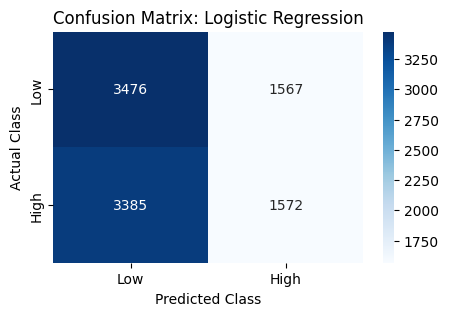

Training Support Vector Machine...

--- Support Vector Machine Performance ---
Accuracy: 0.5054

Classification Report:
              precision    recall  f1-score   support

        High       0.51      0.11      0.18      4957
         Low       0.51      0.90      0.65      5043

    accuracy                           0.51     10000
   macro avg       0.51      0.50      0.41     10000
weighted avg       0.51      0.51      0.41     10000



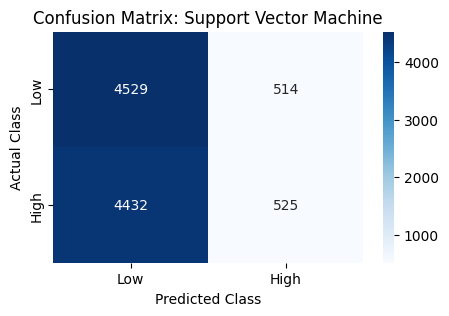

Training Naive Bayes...

--- Naive Bayes Performance ---
Accuracy: 0.5035

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.34      0.40      4957
         Low       0.51      0.67      0.58      5043

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.49     10000



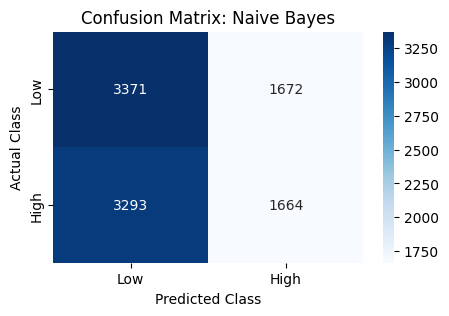

Training Neural Network (MLP)...

--- Neural Network Performance ---
Accuracy: 0.5043

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.86      0.63      4957
         Low       0.53      0.16      0.24      5043

    accuracy                           0.50     10000
   macro avg       0.51      0.51      0.44     10000
weighted avg       0.51      0.50      0.43     10000



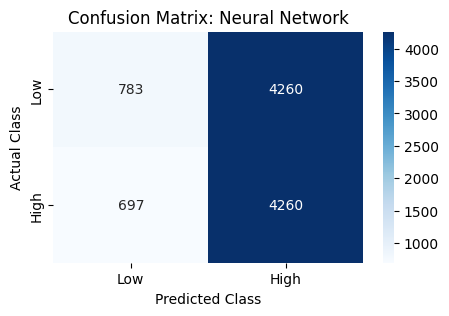

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

# 1. Logistic Regression
print("Training Logistic Regression...")
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)
model_scores['Logistic Regression'] = evaluate_model(log_model, "Logistic Regression")

# 2. Support Vector Machine - SVM
print("Training Support Vector Machine...")
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
model_scores['SVM'] = evaluate_model(svm_model, "Support Vector Machine")

# 3. Naive Bayes
print("Training Naive Bayes...")
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
model_scores['Naive Bayes'] = evaluate_model(nb_model, "Naive Bayes")

# 4. Neural Network
print("Training Neural Network (MLP)...")
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
nn_model.fit(X_train, y_train)
model_scores['Neural Network'] = evaluate_model(nn_model, "Neural Network")

**Step 6** - **Model 5 & Hyperparameter Tuning**: For our 5th model, we will use a **Decision Tree**. To fulfill the "Hyperparameter tuning" requirement from the rubric, we will use **GridSearchCV** to test dozens of depth and splitting rules to find the absolute best version of the Decision Tree to prevent it from overfitting.

Starting Grid Search for Decision Tree (This tests multiple variations)...
Best Parameters Found: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2}

--- Optimized Decision Tree Performance ---
Accuracy: 0.4956

Classification Report:
              precision    recall  f1-score   support

        High       0.49      0.68      0.57      4957
         Low       0.50      0.32      0.39      5043

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.48     10000
weighted avg       0.50      0.50      0.48     10000



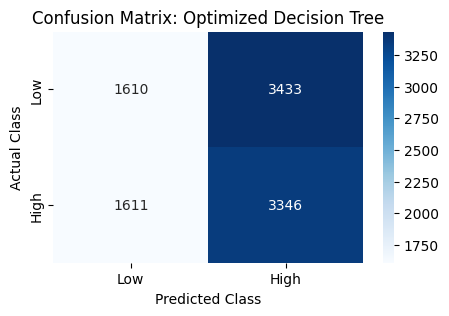

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the "grid" of settings we want to test for the Decision Tree
param_grid = {
    'max_depth': [None, 5, 10, 15, 20],         # How deep the tree can grow
    'min_samples_split': [2, 10, 20],           # Minimum samples required to split a node
    'min_samples_leaf': [1, 5, 10],             # Minimum samples required at a leaf node
    'criterion': ['gini', 'entropy']            # How it measures the quality of a split
}

print("Starting Grid Search for Decision Tree (This tests multiple variations)...")

# Setup the Grid Search
grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           scoring='accuracy')

# Run the tuning process
grid_search.fit(X_train, y_train)

# Extract and evaluate the best model
print(f"Best Parameters Found: {grid_search.best_params_}")
best_dt = grid_search.best_estimator_
model_scores['Optimized Decision Tree'] = evaluate_model(best_dt, "Optimized Decision Tree")

**Feature Importance**: Because Decision Trees naturally calculate the mathematical importance of each feature during training, we can extract the **feature_importances_ array** from our **Optimized Decision Tree**. This creates our most important visualization to answer the core question: "**What makes a Dating profile popular?**"

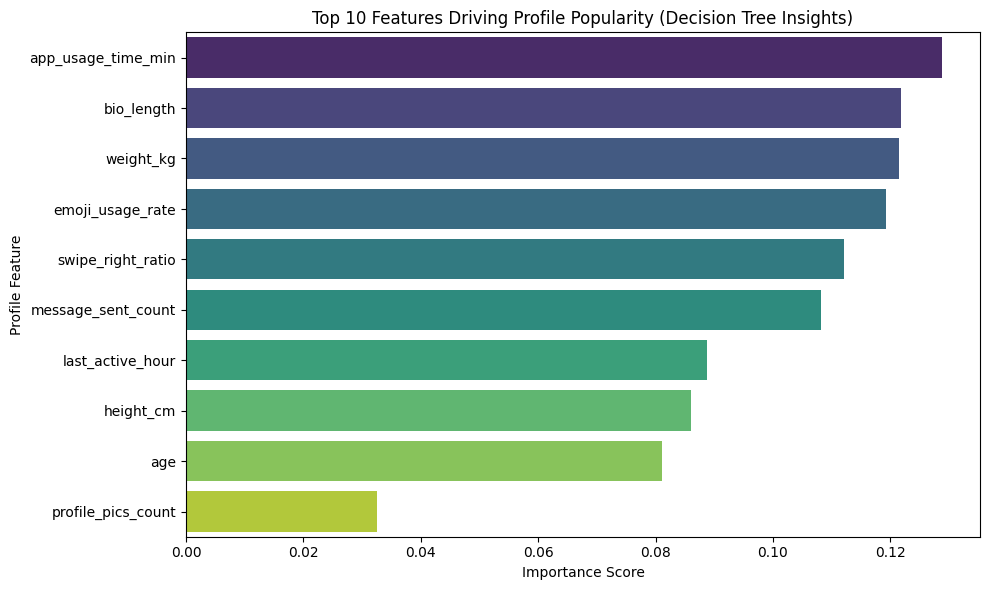


Top 3 Driving Factors for Popularity:
- app_usage_time_min (Score: 0.1288)
- bio_length (Score: 0.1218)
- weight_kg (Score: 0.1215)


In [13]:
# Extract feature importances from the TUNED Decision Tree (best_dt)
importances = best_dt.feature_importances_

# Create a DataFrame to hold the feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort them from most important to least
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the Top 10 most important features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title("Top 10 Features Driving Profile Popularity (Decision Tree Insights)")
plt.xlabel("Importance Score")
plt.ylabel("Profile Feature")
plt.tight_layout()
plt.show()

print("\nTop 3 Driving Factors for Popularity:")
for i, row in feature_importance_df.head(3).iterrows():
    print(f"- {row['Feature']} (Score: {row['Importance']:.4f})")

Step 7 - AutoML Evaluation & Final Comparison
Description: We run the AutoML pipeline, limiting it to 3 minutes to fit within a standard Colab session memory limit. Finally, we plot a comparison chart of all 6 models (our 5 custom + AutoML) to see which performed the best for the final report.

In [23]:
from flaml import AutoML
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize FLAML
automl = AutoML()

# Setup the configuration (3 minutes = 180 seconds)
automl_settings = {
    "time_budget": 180,
    "metric": 'accuracy',
    "task": 'classification',
    "log_file_name": "dating_app_automl.log",
    "seed": 42
}

print("Training Microsoft FLAML (AutoML) pipeline for 3 minutes...")
automl.fit(X_train=X_train, y_train=y_train, **automl_settings)

print(f"\nBest algorithm found by AutoML: {automl.best_estimator}")

# Evaluate using our custom function
model_scores['AutoML (FLAML)'] = evaluate_model(automl, f"AutoML ({automl.best_estimator})")

# FINAL MODEL COMPARISON CHART
plt.figure(figsize=(10, 5))
scores_df = pd.DataFrame(list(model_scores.items()), columns=['Model', 'Accuracy']).sort_values(by='Accuracy', ascending=False)
sns.barplot(x='Accuracy', y='Model', data=scores_df, palette='coolwarm')
plt.title("Final Model Performance Comparison")
plt.xlabel("Accuracy Score")
plt.ylabel("Model")
plt.xlim(0, 1.0)
for index, value in enumerate(scores_df['Accuracy']):
    plt.text(value + 0.01, index, f'{value:.4f}', va='center')
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'flaml'

In [19]:
import joblib

# Export the winning SVM model instead of the Decision tree
joblib.dump(svm_model, 'dating_model_svm.pkl')

print("SVM Model successfully saved as 'dating_model_svm.pkl'!")

SVM Model successfully saved as 'dating_model_svm.pkl'!
